In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

try:
    df = pd.read_csv("/content/my_merged_data.csv", encoding="utf-8")
except:
    df = pd.read_csv("/content/my_merged_data.csv", encoding="latin1")

df.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = ['Production','Export_Quantity','Area_Harvested','Year']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Fill categorical missing values with Unknown
df['Country'] = df['Country'].fillna("Unknown").astype(str)
df['Crop'] = df['Crop'].fillna("Unknown").astype(str)


df['Domestic_Requirement'] = df['Production'] - df['Export_Quantity']

print("DATA LOADED SUCCESSFULLY", df.shape)

DATA LOADED SUCCESSFULLY (36890, 7)


In [ ]:

common_prices = {
    'Wheat': 220.0, 'Rice': 260.0, 'Maize': 180.0, 'Maize (Corn)': 180.0,
    'Cotton': 1500.0, 'Soybean': 500.0, 'Sugarcane': 35.0, 'Barley': 180.0,
    'Sorghum': 170.0, 'Millet': 160.0, 'Groundnut': 700.0, 'Rapeseed': 420.0,
    'Sunflower': 520.0, 'Potato': 120.0, 'Tomato': 300.0, 'Onion': 200.0,
    'Tea': 2500.0, 'Coffee': 3000.0, 'Rubber': 1500.0
}

default_price = 180.0
df['Crop_Price'] = df['Crop'].map(common_prices).fillna(default_price)

min_year = int(df['Year'].min())
np.random.seed(42)
year_factor = df['Year'].apply(lambda y: 1 + 0.02 * (y - min_year))
noise = np.random.normal(0, 0.06, size=len(df))

df['Market_Price'] = df['Crop_Price'] * year_factor * (1 + noise)
df['Export_Price'] = df['Market_Price'] * 1.10

# Cost per ton
df['Cost_per_ton'] = 50
print("DEFAULT PRICES ARE FILLED SUCCESSFULLY")




DEFAULT PRICES ARE FILLED SUCCESSFULLY


In [ ]:

df['Roll_Export'] = df['Export_Quantity'].rolling(3, min_periods=1).mean()
df['Roll_Demand'] = df['Domestic_Requirement'].rolling(3, min_periods=1).mean()

df['Export_Potential'] = (df['Roll_Export'] > df['Roll_Demand']).astype(int)

# Drop helper columns
df.drop(['Roll_Export','Roll_Demand'], axis=1, inplace=True)

print("Take the average of the last 3 years (current year + previous 2).\n And Create export potential ")


Take the average of the last 3 years (current year + previous 2).
 And Create export potential 


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = ['Country', 'Crop']

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_array = encoder.fit_transform(df[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)
df_encoded_part = pd.DataFrame(encoded_array, columns=encoded_cols)

# Drop original categorical columns
df_clean = df.drop(columns=categorical_cols).reset_index(drop=True)

# Merge numeric + encoded columns
df_encoded = pd.concat([df_clean, df_encoded_part], axis=1)

print("SKLEARN ENCODING COMPLETE ✓")
print("Encoded shape:", df_encoded.shape)


SKLEARN ENCODING COMPLETE ✓
Encoded shape: (36890, 363)


In [ ]:
['Year', 'Area_Harvested', 'Crop_Price']


['Year', 'Area_Harvested', 'Crop_Price']

In [ ]:
print("TRAINING REGRESSION MODELS")

reg_features = ['Year', 'Area_Harvested', 'Crop_Price']
Xr = df[reg_features]
yr = df['Market_Price']

from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

# 1️ Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)

# 2️ Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(Xr_train, yr_train)

# 3️ Voting Ensemble (Linear + RF)
voting_reg = VotingRegressor([
    ('lr', lin_reg),
    ('rf', rf_reg)
])
voting_reg.fit(Xr_train, yr_train)

print("All 3 regression models trained successfully.\n")


TRAINING REGRESSION MODELS
All 3 regression models trained successfully.



In [ ]:
['Year', 'Area_Harvested', 'Crop_Price', 'Market_Price']


['Year', 'Area_Harvested', 'Crop_Price', 'Market_Price']

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


lin_reg = LinearRegression()
lin_reg.fit(Xr_train, yr_train)

# Train Voting Ensemble (new)
voting_reg = VotingRegressor([
    ('lin', lin_reg),
    ('rf', rf_reg)
])
voting_reg.fit(Xr_train, yr_train)

# Function to compute metrics
def reg_metrics(model, X_test, y_test):
    pred = model.predict(X_test)
    return {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    }

metrics_lin_reg  = reg_metrics(lin_reg, Xr_test, yr_test)   # Linear Regression
metrics_rf_reg   = reg_metrics(rf_reg, Xr_test, yr_test)    # Random Forest Regression
metrics_vote_reg = reg_metrics(voting_reg, Xr_test, yr_test) # Voting Regressor

print(" REGRESSION MODEL PERFORMANCE\n")

print("1️ Linear Regression:")
for k, v in metrics_lin_reg.items():
    print(f"   {k}: {float(v):.4f}")

print("\n2️ Random Forest Regressor:")
for k, v in metrics_rf_reg.items():
    print(f"   {k}: {float(v):.4f}")

print("\n3️ Voting Ensemble Regressor:")
for k, v in metrics_vote_reg.items():
    print(f"   {k}: {float(v):.4f}")



 REGRESSION MODEL PERFORMANCE

1️ Linear Regression:
   RMSE: 13.7015
   MAE: 10.8424
   R2: 0.8607

2️ Random Forest Regressor:
   RMSE: 15.8723
   MAE: 12.4702
   R2: 0.8131

3️ Voting Ensemble Regressor:
   RMSE: 14.2427
   MAE: 11.2505
   R2: 0.8495


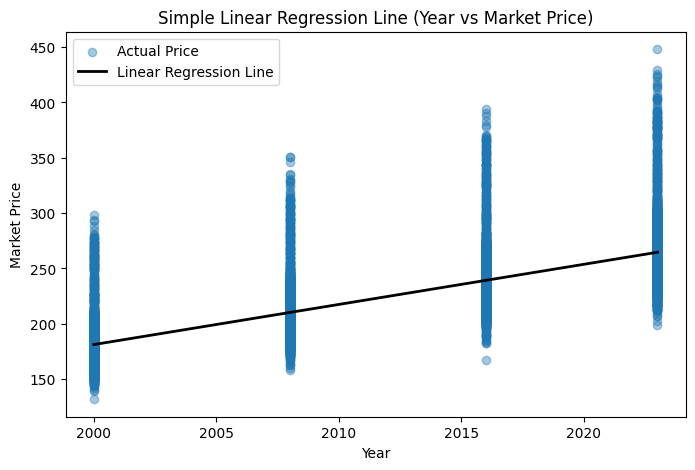

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np


X_year = Xr_train['Year'].values.reshape(-1, 1)
y_price = yr_train.values


line_model = LinearRegression()
line_model.fit(X_year, y_price)


X_sorted = np.sort(X_year, axis=0)
y_pred_line = line_model.predict(X_sorted)

plt.figure(figsize=(8,5))
plt.scatter(X_year, y_price, alpha=0.4, label="Actual Price")
plt.plot(X_sorted, y_pred_line, linewidth=2, label="Linear Regression Line", color="black")

plt.xlabel("Year")
plt.ylabel("Market Price")
plt.title("Simple Linear Regression Line (Year vs Market Price)")
plt.legend()
plt.show()


In [ ]:
print("TRAINING CLASSIFICATION MODELS ")

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

clf_features = ['Year', 'Area_Harvested', 'Crop_Price', 'Market_Price']

Xc = df[clf_features]
yc = df['Export_Potential']   # 0/1 class

from sklearn.model_selection import train_test_split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.20, random_state=42, stratify=yc
)


smote = SMOTE(random_state=42)
Xc_bal, yc_bal = smote.fit_resample(Xc_train, yc_train)


# 1️ Logistic Regression
log_clf = LogisticRegression(max_iter=3000)
log_clf.fit(Xc_bal, yc_bal)

# 2️ Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_clf.fit(Xc_bal, yc_bal)

# 3️ Voting Classifier (Best model)
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf)],
    voting='soft'
)
voting_clf.fit(Xc_bal, yc_bal)

print("\nAll classification models trained successfully with balanced data.\n")


TRAINING CLASSIFICATION MODELS 

All classification models trained successfully with balanced data.



In [ ]:
print("CLASSIFICATION PERFORMANCE (3 MODELS)")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def clf_metrics(model, Xtest, ytest):
    pred = model.predict(Xtest)
    proba = model.predict_proba(Xtest)[:,1]

    return {
        "Accuracy": accuracy_score(ytest, pred),
        "Precision": precision_score(ytest, pred, zero_division=0),
        "Recall": recall_score(ytest, pred, zero_division=0),
        "F1 Score": f1_score(ytest, pred, zero_division=0),
        "ROC AUC": roc_auc_score(ytest, proba),
        "Confusion Matrix": confusion_matrix(ytest, pred)
    }

# Calculate metrics
metrics_log   = clf_metrics(log_clf, Xc_test, yc_test)
metrics_rf    = clf_metrics(rf_clf, Xc_test, yc_test)
metrics_vote  = clf_metrics(voting_clf, Xc_test, yc_test)


def print_metrics(name, metrics):
    print(f"\n {name} Performance:")
    print("------------------------------")
    print(f"Accuracy        : {metrics['Accuracy']:.4f}")
    print(f"Precision       : {metrics['Precision']:.4f}")
    print(f"Recall          : {metrics['Recall']:.4f}")
    print(f"F1 Score        : {metrics['F1 Score']:.4f}")
    print(f"ROC AUC         : {metrics['ROC AUC']:.4f}")
    print("Confusion Matrix:")
    print(metrics['Confusion Matrix'])
    print("------------------------------")

print_metrics("Logistic Regression", metrics_log)
print_metrics("Random Forest Classifier", metrics_rf)
print_metrics("Voting Classifier", metrics_vote)


CLASSIFICATION PERFORMANCE (3 MODELS)

 Logistic Regression Performance:
------------------------------
Accuracy        : 0.5549
Precision       : 0.9448
Recall          : 0.5537
F1 Score        : 0.6982
ROC AUC         : 0.5746
Confusion Matrix:
[[ 295  222]
 [3062 3799]]
------------------------------

 Random Forest Classifier Performance:
------------------------------
Accuracy        : 0.8246
Precision       : 0.9323
Recall          : 0.8749
F1 Score        : 0.9027
ROC AUC         : 0.5403
Confusion Matrix:
[[  81  436]
 [ 858 6003]]
------------------------------

 Voting Classifier Performance:
------------------------------
Accuracy        : 0.8197
Precision       : 0.9327
Recall          : 0.8688
F1 Score        : 0.8996
ROC AUC         : 0.5620
Confusion Matrix:
[[  87  430]
 [ 900 5961]]
------------------------------


In [ ]:

def best_crops_global(top_n=5):
    df_exp = df.groupby("Crop")["Export_Quantity"].mean().sort_values(ascending=False)
    return df_exp.head(top_n)


def best_crop_for_country(country):
    subset = df[df["Country"] == country]
    if subset.empty:
        return None
    return subset.groupby("Crop")["Export_Quantity"].mean().idxmax()


def country_needing_crop(crop, exclude_country=None):
    df_crop = df[df["Crop"] == crop]

    # ⭐ FIX: Exclude the current selected country
    if exclude_country:
        df_crop = df_crop[df_crop["Country"] != exclude_country]

    if df_crop.empty:
        return "No country needs this crop"

    need_rank = df_crop.groupby("Country")["Domestic_Requirement"].mean().sort_values(ascending=False)
    return need_rank.index[0]

In [ ]:
def make_forecast(country, crop, year):

    df_filtered = df[(df['Country'] == country) & (df['Crop'] == crop)]

    if df_filtered.empty:
        return {"Error": "No matching data found for this Country-Crop selection."}

    df_grouped = df_filtered.groupby("Year", as_index=False).mean(numeric_only=True)

    if len(df_grouped) < 2:
        return {"Error": "Not enough past data to forecast."}

    # Train forecasting models
    from sklearn.linear_model import LinearRegression

    prod_model = LinearRegression().fit(df_grouped[['Year']], df_grouped['Production'])
    area_model = LinearRegression().fit(df_grouped[['Year']], df_grouped['Area_Harvested'])
    demand_model = LinearRegression().fit(df_grouped[['Year']], df_grouped['Domestic_Requirement'])

    future = pd.DataFrame({'Year': [year]})

    pred_prod = float(prod_model.predict(future)[0])
    pred_area = float(area_model.predict(future)[0])
    pred_demand = float(demand_model.predict(future)[0])

    pred_import = max(pred_demand - pred_prod, 0)
    pred_export = max(pred_prod - pred_demand, 0)

    # PRICE PREDICTION using your regression model (lin_reg)
    price_input = pd.DataFrame({
        'Year': [year],
        'Area_Harvested': [pred_area],
        'Crop_Price': [df_filtered['Crop_Price'].iloc[0]]
    })

    pred_price = float(lin_reg.predict(price_input)[0])

    # Yield per hectare
    yield_per_ha = pred_prod / pred_area if pred_area > 0 else 0

    # Profit per hectare
    cost = 50
    profit_per_ha = (pred_price - cost) * yield_per_ha

    return {
        "Predicted_Production": pred_prod,
        "Predicted_Area": pred_area,
        "Domestic_Requirement": pred_demand,
        "Predicted_Import": pred_import,
        "Predicted_Export": pred_export,
        "Predicted_Price": pred_price,
        "Yield_per_Hectare": yield_per_ha,
        "Profit_per_Hectare": profit_per_ha
    }


In [ ]:
print(make_forecast("India", "Wheat", 2030))


{'Predicted_Production': 116750802.80488634, 'Predicted_Area': 32684231.07666385, 'Domestic_Requirement': 49618031.740235865, 'Predicted_Import': 0, 'Predicted_Export': 67132771.06465048, 'Predicted_Price': 339.8226809076232, 'Yield_per_Hectare': 3.572083508130776, 'Profit_per_Hectare': 1035.270818752369}


In [ ]:
# print("FINAL DASHBOARD")

# import ipywidgets as widgets
# from IPython.display import display, clear_output
# import pandas as pd

# # UI elements
# country_dd = widgets.Dropdown(
#     options=sorted(df['Country'].unique()),
#     description="Country:",
#     layout=widgets.Layout(width="40%")
# )

# crop_dd = widgets.Dropdown(
#     options=sorted(df['Crop'].unique()),
#     description="Crop:",
#     layout=widgets.Layout(width="40%")
# )

# year_slider = widgets.IntSlider(
#     value=2030,
#     min=int(df['Year'].min()),
#     max=int(df['Year'].max())+20,
#     step=1,
#     description="Year:",
#     layout=widgets.Layout(width="80%")
# )

# predict_btn = widgets.Button(
#     description="🔮 Predict",
#     button_style="success"
# )

# output_box = widgets.Output()

# def on_predict(btn):
#     with output_box:
#         clear_output()

#         country = country_dd.value
#         crop = crop_dd.value
#         year = year_slider.value

#         # FORECAST
#         result = make_forecast(country, crop, year)

#         print("📈 FORECAST RESULTS")
#         for key, val in result.items():
#             print(f"{key}: {val}")

#         print("\nTop Export Crops Globally:")
#         print(best_crops_global())

#         print(f"\nBest Export Crop in {country}:")
#         print(best_crop_for_country(country))

#         print(f"\nCountry that needs {crop} most:")
#         print(country_needing_crop(crop))

#         forecast_df = pd.DataFrame([result])
#         forecast_df.insert(0, "Country", country)
#         forecast_df.insert(1, "Crop", crop)
#         forecast_df.insert(2, "Year", year)

#         csv_btn = widgets.Button(description="📥 Download CSV", button_style="info")

#         def save_csv(ev):
#             filename = f"{country}_{crop}_{year}_forecast.csv".replace(" ", "_")
#             forecast_df.to_csv(filename, index=False)
#             print(f"\n✅ CSV saved as: {filename}")

#         csv_btn.on_click(save_csv)
#         display(csv_btn)

# # Bind click event
# predict_btn.on_click(on_predict)

# # Display UI
# display(widgets.HBox([country_dd, crop_dd]))
# display(year_slider)
# display(predict_btn)
# display(output_box)


In [ ]:
!pip install pyngrok


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("365uES6rMc477eDnwPUQty3fyNg_25LLARsyXUT7WtWtabpbs")


In [ ]:
df.to_csv("/content/processed_agri_data.csv", index=False)
print("Processed data saved!")


Processed data saved!


In [ ]:
!pip install flask pyngrok pandas numpy scikit-learn


In [ ]:
!mkdir templates


In [ ]:
%%writefile templates/index.html
<!DOCTYPE html>
<html>
<head>
    <title>AgriPredict Dashboard</title>

    <style>
        body {
            background-image: url('https://images.unsplash.com/photo-1500382017468-9049fed747ef?auto=format&fit=crop&w=1350&q=80');
            background-size: cover;
            background-repeat: no-repeat;
            background-position: center;
            background-attachment: fixed;
        }
        .overlay {
            background: rgba(255, 255, 255, 0.82);
            backdrop-filter: blur(4px);
            min-height: 100vh;
            padding: 20px;
        }
    </style>

    <link rel="stylesheet"
     href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css">
</head>

<body>
<div class="overlay">

    <h2 class="text-center mb-4">🌾 AI Based Crop Forecasting Dashboard</h2>

    <div class="card p-4 shadow">
        <form method="POST" action="/predict">
            <div class="row">
                <div class="col-md-4">
                    <label>Country</label>
                    <select class="form-select" name="country" required>
                        {% for c in countries %}
                            <option value="{{c}}">{{c}}</option>
                        {% endfor %}
                    </select>
                </div>

                <div class="col-md-4">
                    <label>Crop</label>
                    <select class="form-select" name="crop" required>
                        {% for c in crops %}
                            <option value="{{c}}">{{c}}</option>
                        {% endfor %}
                    </select>
                </div>

                <div class="col-md-4">
                    <label>Year</label>
                    <input type="number" class="form-control" name="year" value="2030" required>
                </div>
            </div>

            <button class="btn btn-success w-100 mt-3">Predict 🔮</button>
        </form>
    </div>

    {% if error %}
        <div class="alert alert-danger mt-3">{{error}}</div>
    {% endif %}

    {% if result_table %}
    <div class="card mt-4 p-3 shadow">
        <h4>📈 Forecast Results</h4>
        {{ result_table|safe }}

        <form method="POST" action="/download">
            <input type="hidden" name="csv_data" value="{{ result_table }}">
            <button class="btn btn-info mt-2">📥 Download CSV</button>
        </form>
    </div>
    {% endif %}

    {% if top_global %}
    <div class="card mt-4 p-3 shadow">
        <h4>🌍 Global Insights</h4>

        <div class="row">
            <div class="col-md-4">
                <h5>Top Export Crops</h5>
                <ul>
                    {% for k,v in top_global.items() %}
                    <li>{{k}} — {{v}}</li>
                    {% endfor %}
                </ul>
            </div>

            <div class="col-md-4">
                <h5>Best Crop in {{selected_country}}</h5>
                <div class="alert alert-success">{{best_in_country}}</div>
            </div>

            <div class="col-md-4">
                <h5>Country Needing {{selected_crop}}</h5>
                <div class="alert alert-info">{{needing_country}}</div>
            </div>
        </div>
    </div>
    {% endif %}

</div>
</body>
</html>


Writing templates/index.html


In [ ]:
%%writefile app.py
from flask import Flask, render_template, request, send_file
import pandas as pd
import numpy as np
import io
from sklearn.linear_model import LinearRegression

# Load the processed data
df = pd.read_csv("/content/processed_agri_data.csv")
df.columns = [c.strip() for c in df.columns]

# Insight functions
def best_crops_global(top_n=5):
    return df.groupby("Crop")["Export_Quantity"].mean().sort_values(ascending=False).head(top_n)

def best_crop_for_country(country):
    subset = df[df["Country"] == country]
    if subset.empty:
        return "No data"
    return subset.groupby("Crop")["Export_Quantity"].mean().idxmax()

def country_needing_crop(crop, exclude_country=None):
    subset = df[df["Crop"] == crop]
    if exclude_country:
        subset = subset[subset["Country"] != exclude_country]
    return subset.groupby("Country")["Domestic_Requirement"].mean().sort_values(ascending=False).index[0]

# Forecast function
def make_forecast(country, crop, year):
    subset = df[(df["Country"] == country) & (df["Crop"] == crop)]

    if subset.empty:
        return {"Error": "No matching Country-Crop data found."}

    # Group by year correctly (numeric only)
    df_year = subset.groupby("Year", as_index=False).mean(numeric_only=True)

    if len(df_year) < 2:
        return {"Error": "Not enough past data to forecast."}

    from sklearn.linear_model import LinearRegression

    # Train 3 linear models
    prod_model = LinearRegression().fit(df_year[['Year']], df_year['Production'])
    area_model = LinearRegression().fit(df_year[['Year']], df_year['Area_Harvested'])
    demand_model = LinearRegression().fit(df_year[['Year']], df_year['Domestic_Requirement'])

    # Prepare future
    future = pd.DataFrame({'Year': [year]})

    pred_prod = float(prod_model.predict(future)[0])
    pred_area = float(area_model.predict(future)[0])
    pred_demand = float(demand_model.predict(future)[0])

    pred_export = max(pred_prod - pred_demand, 0)
    pred_import = max(pred_demand - pred_prod, 0)

    mean_price = subset['Market_Price'].mean()
    mean_export_price = subset['Export_Price'].mean()
    cost = subset['Cost_per_ton'].mean()

    yield_per_ha = pred_prod / pred_area if pred_area > 0 else 0
    profit_per_ha = (mean_price - cost) * yield_per_ha

    return {
        "Predicted_Production": round(pred_prod, 3),
        "Predicted_Area": round(pred_area, 3),
        "Domestic_Requirement": round(pred_demand, 3),
        "Predicted_Import": round(pred_import, 3),
        "Predicted_Export": round(pred_export, 3),
        "Predicted_Price": round(mean_price, 3),
        "Predicted_Export_Price": round(mean_export_price, 3),
        "Yield_per_Hectare": round(yield_per_ha, 3),
        "Profit_per_Hectare": round(profit_per_ha, 3)
    }


app = Flask(__name__)

@app.route("/")
def home():
    return render_template("index.html",
        countries=sorted(df["Country"].unique()),
        crops=sorted(df["Crop"].unique()))

@app.route("/predict", methods=["POST"])
def predict():
    country = request.form["country"]
    crop = request.form["crop"]
    year = int(request.form["year"])

    result = make_forecast(country, crop, year)

    if "Error" in result:
        return render_template("index.html",
            error=result["Error"],
            countries=sorted(df["Country"].unique()),
            crops=sorted(df["Crop"].unique()))

    out_df = pd.DataFrame([result])
    out_df.insert(0, "Country", country)
    out_df.insert(1, "Crop", crop)
    out_df.insert(2, "Year", year)

    return render_template("index.html",
        countries=sorted(df["Country"].unique()),
        crops=sorted(df["Crop"].unique()),
        result_table=out_df.to_html(classes="table table-bordered", index=False),
        top_global=best_crops_global().to_dict(),
        best_in_country=best_crop_for_country(country),
        needing_country=country_needing_crop(crop, exclude_country=country),
        selected_country=country,
        selected_crop=crop,
        selected_year=year)

@app.route("/download", methods=["POST"])
def download():
    html_data = request.form["csv_data"]
    temp_df = pd.read_html(html_data)[0]
    buffer = io.BytesIO()
    temp_df.to_csv(buffer, index=False)
    buffer.seek(0)
    return send_file(buffer, as_attachment=True, download_name="forecast.csv")

from pyngrok import ngrok

if __name__ == "__main__":
    public_url = ngrok.connect(5000)
    print("🌐 PUBLIC URL:", public_url)
    app.run(host="0.0.0.0", port=5000)


Writing app.py


In [ ]:
!python app.py


🌐 PUBLIC URL: NgrokTunnel: "https://nonorientable-marina-unsolubly.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app 'app'
 * Debug mode: off
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
Press CTRL+C to quit
127.0.0.1 - - [01/Dec/2025 08:41:46] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [01/Dec/2025 08:41:49] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [01/Dec/2025 08:42:45] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [01/Dec/2025 08:43:20] "POST /predict HTTP/1.1" 200 -
